<a href="https://colab.research.google.com/github/gbaranaos/iele756-region-4/blob/main/Tarea1_comuna_13101_Santiago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 — Demographic Profile & Migration Landscape

**Curso:** IELE756 – Preparación y Análisis de Datos  
**Alumno:** Guillermo Barañao  
**Fecha:** 26 Marzo 2026



## 0. Instalación de paquetes



In [ ]:
 !pip -q install pyarrow openpyxl geopandas pyogrio

## 1. Configuración

### Definir comuna

Subir archivos


In [1]:
# =========================
# CONFIGURACIÓN
# =========================

MY_COMUNAS = [13101]

# Archivos subidos
PATH_VIVIENDA = "viviendas_censo2024.parquet"
PATH_HOGAR = "hogares_censo2024.parquet"
PATH_PERSONA = "personas_censo2024.parquet"

# Archivos
PATH_DICCIONARIO = "diccionario_variables_censo2024.xlsx"
PATH_SHAPEFILE = "comunas.shp"


COMUNA_NAME_OVERRIDE = {
    13101: "Santiago",
}

OUTPUT_DIR = "output"

## 2. Librerías

In [2]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pyarrow.dataset as ds
except Exception as e:
    raise ImportError("Necesitas pyarrow. Si estás en Colab, ejecuta la celda de instalación.") from e

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore")

## 3. Funciones auxiliares

Aquí definimos funciones para:

- cargar solo columnas necesarias,
- filtrar temprano por comuna o región,
- limpiar valores faltantes codificados como `-99`, `-66`, etc.,
- y crear nombres de comuna de respaldo cuando no exista un archivo externo con esa información.

In [3]:
MISSING_CODES = {-99, -98, -97, -96, -88, -77, -66}

def clean_missing(series):
    return series.replace(list(MISSING_CODES), np.nan)

def load_parquet_filtered(path, columns, comuna_codes=None, region_code=None, comuna_col="comuna", region_col="region"):
    dataset = ds.dataset(path, format="parquet")
    filt = None

    if comuna_codes:
        filt = ds.field(comuna_col).isin(list(comuna_codes))
    elif region_code is not None:
        filt = ds.field(region_col) == region_code

    table = dataset.to_table(columns=columns, filter=filt)
    return table.to_pandas()

def fallback_comuna_name_map(codes):
    out = {}
    for c in sorted(pd.Series(codes).dropna().astype(int).unique()):
        out[c] = COMUNA_NAME_OVERRIDE.get(c, f"Comuna {c}")
    return out

def detect_or_build_comuna_name_map(df_codes):
    # 1) primero usar override manual
    code_set = sorted(pd.Series(df_codes).dropna().astype(int).unique())
    mapping = {c: COMUNA_NAME_OVERRIDE.get(c) for c in code_set if c in COMUNA_NAME_OVERRIDE}

    # 2) si no hay nada, usar fallback
    if len(mapping) < len(code_set):
        fallback = fallback_comuna_name_map(code_set)
        for k, v in fallback.items():
            mapping.setdefault(k, v)

    return mapping

def dependency_ratio_from_series(age_series):
    age = clean_missing(age_series)
    dep = ((age.between(0, 14, inclusive="both")).sum() + (age >= 65).sum())
    work = age.between(15, 64, inclusive="both").sum()
    return np.nan if work == 0 else dep / work

def make_optional_dictionary(path):
    if os.path.exists(path):
        dic = pd.read_excel(path)
        dic.columns = [str(c).strip() for c in dic.columns]
        return dic
    return None

def get_var_dict(dic, var_name):
    if dic is None:
        return pd.DataFrame()
    if "nombre_variable" not in dic.columns:
        return pd.DataFrame()
    tmp = dic[dic["nombre_variable"] == var_name].copy()
    cols = [c for c in ["nombre_variable", "valor", "etiqueta_de_categoria"] if c in tmp.columns]
    if not cols:
        return pd.DataFrame()
    tmp = tmp[cols].copy()
    if "valor" in tmp.columns:
        tmp["valor"] = pd.to_numeric(tmp["valor"], errors="coerce")
    return tmp.dropna(subset=["valor"])

def build_map(dic, var_name):
    tmp = get_var_dict(dic, var_name)
    if tmp.empty:
        return {}
    return dict(zip(tmp["valor"].astype(int), tmp["etiqueta_de_categoria"]))

def code_to_label(series, mapping, prefix="Código"):
    if mapping:
        return series.map(mapping)
    return series.apply(lambda x: np.nan if pd.isna(x) else f"{prefix} {int(x)}")

def normalize_age_group(df, age_col="edad"):
    bins = list(range(0, 81, 5)) + [200]
    labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
    out = df.copy()
    out["age_group"] = pd.cut(out[age_col], bins=bins, labels=labels, right=False)
    return out, labels

## 4. Validación de filtros



In [4]:
if not MY_COMUNAS and MY_REGION is None:
    raise ValueError("Debes definir MY_COMUNAS o MY_REGION en la celda de configuración antes de seguir.")

print("Filtro activo:")
if MY_COMUNAS:
    print("Comunas:", MY_COMUNAS)
else:
    print("Región:", MY_REGION)

Filtro activo:
Comunas: [13101]


## 5. Cargar columnas necesarias desde los `.parquet`


Además, el nombre de la comuna **no viene** dentro de los `.parquet`, así que lo construiremos con un fallback.

In [5]:
# Columnas reales disponibles
cols_viv_real = [
    "id_vivienda", "region", "provincia", "comuna",
    "indice_hacinamiento",
    "p4a_mat_paredes", "p4b_mat_techo", "p4c_mat_piso"
]

cols_hog_real = [
    "id_vivienda", "id_hogar", "region", "comuna",
    "p12_tenencia_viv", "tipologia_hogar"
]

cols_per_real = [
    "id_vivienda", "id_hogar", "id_persona", "region", "comuna",
    "sexo", "edad", "p27_nacionalidad_esp", "p25_lug_nacimiento_rec",
    "p24_lug_resid5", "p25_lug_nacimiento", "p26_llegada_periodo",
    "escolaridad", "cine11", "sit_fuerza_trabajo",
    "cod_ciuo", "cod_caenes", "p45_medio_transporte"
]

vivienda = load_parquet_filtered(
    PATH_VIVIENDA,
    cols_viv_real,
    comuna_codes=MY_COMUNAS if MY_COMUNAS else None,
    region_code=MY_REGION if not MY_COMUNAS else None,
    comuna_col="comuna",
    region_col="region"
)

hogar = load_parquet_filtered(
    PATH_HOGAR,
    cols_hog_real,
    comuna_codes=MY_COMUNAS if MY_COMUNAS else None,
    region_code=MY_REGION if not MY_COMUNAS else None,
    comuna_col="comuna",
    region_col="region"
)

persona = load_parquet_filtered(
    PATH_PERSONA,
    cols_per_real,
    comuna_codes=MY_COMUNAS if MY_COMUNAS else None,
    region_code=MY_REGION if not MY_COMUNAS else None,
    comuna_col="comuna",
    region_col="region"
)

print("Filas vivienda filtrada:", len(vivienda))
print("Filas hogar filtrada:", len(hogar))
print("Filas persona filtrada:", len(persona))

Filas vivienda filtrada: 241062
Filas hogar filtrada: 208348
Filas persona filtrada: 438856


## 6. Estandarizar nombres de columnas


In [6]:
vivienda = vivienda.rename(columns={
    "comuna": "codigo_comuna",
    "indice_hacinamiento": "hacinamiento"
})

hogar = hogar.rename(columns={
    "comuna": "codigo_comuna",
    "p12_tenencia_viv": "tenencia"
})

persona = persona.rename(columns={
    "comuna": "codigo_comuna"
})

# Como no tenemos nombre de comuna en los parquet, creamos uno de respaldo
comuna_name_map = detect_or_build_comuna_name_map(vivienda["codigo_comuna"])

vivienda["nombre_comuna"] = vivienda["codigo_comuna"].map(comuna_name_map)
hogar["nombre_comuna"] = hogar["codigo_comuna"].map(comuna_name_map)
persona["nombre_comuna"] = persona["codigo_comuna"].map(comuna_name_map)

display(vivienda.head())
display(hogar.head())
display(persona.head())

,id_vivienda,region,provincia,codigo_comuna,hacinamiento,p4a_mat_paredes,p4b_mat_techo,p4c_mat_piso,nombre_comuna
0,9,13,131,13101,1.0,5.0,1.0,3.0,Santiago
1,11,13,131,13101,1.0,1.0,2.0,1.0,Santiago
2,31,13,131,13101,1.0,2.0,2.0,1.0,Santiago
3,38,13,131,13101,1.0,1.0,2.0,1.0,Santiago
4,63,13,131,13101,1.0,5.0,3.0,3.0,Santiago


,id_vivienda,id_hogar,region,codigo_comuna,tenencia,tipologia_hogar,nombre_comuna
0,9,1,13,13101,1.0,3.0,Santiago
1,11,1,13,13101,6.0,7.0,Santiago
2,31,1,13,13101,3.0,1.0,Santiago
3,38,1,13,13101,3.0,7.0,Santiago
4,63,1,13,13101,6.0,5.0,Santiago


,id_vivienda,id_hogar,id_persona,region,codigo_comuna,sexo,edad,p27_nacionalidad_esp,p25_lug_nacimiento_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,escolaridad,cine11,sit_fuerza_trabajo,cod_ciuo,cod_caenes,p45_medio_transporte,nombre_comuna
0,9,1,1,13,13101,2,78,152,1,2,1,NaN,10,5,3.0,NaN,None,NaN,Santiago
1,9,1,2,13,13101,1,82,152,1,2,1,NaN,4,3,3.0,NaN,None,NaN,Santiago
2,11,1,1,13,13101,2,33,152,1,2,2,NaN,19,9,1.0,2.0,Q,2.0,Santiago
3,11,1,2,13,13101,1,20,152,1,3,2,NaN,13,6,3.0,NaN,None,NaN,Santiago
4,31,1,1,13,13101,1,37,152,1,2,2,NaN,23,11,1.0,3.0,G,2.0,Santiago


## 7. Join de persona + hogar + vivienda


1. unir `persona` con `hogar` por `id_vivienda` e `id_hogar`,
2. luego unir el resultado con `vivienda` por `id_vivienda`,
3. y verificar que la cantidad final de filas coincida con la tabla de personas filtrada.

In [7]:
df = (
    persona.merge(
        hogar[["id_vivienda", "id_hogar", "tenencia", "tipologia_hogar"]],
        on=["id_vivienda", "id_hogar"],
        how="left"
    )
    .merge(
        vivienda[[
            "id_vivienda", "region", "provincia", "codigo_comuna", "nombre_comuna",
            "hacinamiento", "p4a_mat_paredes", "p4b_mat_techo", "p4c_mat_piso"
        ]],
        on="id_vivienda",
        how="left",
        suffixes=("", "_viv")
    )
)

assert len(df) == len(persona), "Row count mismatch after join!"

print("Shape final:", df.shape)
df.info()

Shape final: (438856, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438856 entries, 0 to 438855
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             438856 non-null  int32  
 1   id_hogar                438856 non-null  int32  
 2   id_persona              438856 non-null  int32  
 3   region                  438856 non-null  int32  
 4   codigo_comuna           438856 non-null  int32  
 5   sexo                    438856 non-null  int32  
 6   edad                    438856 non-null  int32  
 7   p27_nacionalidad_esp    438856 non-null  int32  
 8   p25_lug_nacimiento_rec  438856 non-null  int32  
 9   p24_lug_resid5          438856 non-null  int32  
 10  p25_lug_nacimiento      438856 non-null  int32  
 11  p26_llegada_periodo     176956 non-null  float64
 12  escolaridad             438856 non-null  int32  
 13  cine11                  438856 non-null  int32  

## 8. Cargar diccionario de variables si lo tienes

La pauta insiste en tener abierto `diccionario_variables_censo2024.xlsx`.  
Si subes ese archivo al mismo directorio, el notebook intentará usarlo automáticamente para:

- decodificar nacionalidades,
- decodificar residencia hace 5 años,
- decodificar período de llegada,
- y confirmar la codificación de empleo.

Si no lo tienes, el notebook usará **fallbacks razonables** para seguir avanzando, pero conviene reemplazarlos antes de entregar.

In [8]:
dic = make_optional_dictionary(PATH_DICCIONARIO)

if dic is None:
    print("No se encontró el diccionario de variables. Se usarán fallback mappings cuando sea posible.")
else:
    print("Diccionario cargado correctamente.")
    display(dic.head())

Diccionario cargado correctamente.


,Entidad,Nombre variable,Descripción de la variable,Valor,Etiqueta de categoría,Rango,Universo,Conteo
0,Vivienda,id_vivienda,Llave identificadora de la vivienda o de la en...,1:7664466,Válidos,1:7664466,Todos los registros,7664466
1,Vivienda,region,Región,1:16,Ver diccionario códigos territoriales,1:16,Todos los registros,7664466
2,Vivienda,provincia,Provincia,11:163,Ver diccionario códigos territoriales,11:163,Todos los registros,7664466
3,Vivienda,comuna,Comuna,1101:16305,Ver diccionario códigos territoriales,1101:16305,Todos los registros,7664466
4,Vivienda,area,Área urbana o rural,1,Urbano,1:2,Todos los registros,6365998


## 9. Mapas de decodificación


- `sexo`: 1 = Hombre, 2 = Mujer
- `p25_lug_nacimiento_rec`: 1 = Chilean-born, 2 = Foreign-born
- `sit_fuerza_trabajo`: por defecto tratamos `1` como ocupado/a
- `p24_lug_resid5`: fallback propuesto  
  - 2 = Same comuna  
  - 3 = Different comuna, same region  
  - 1 = Different region  
  - 4 = Abroad

In [9]:
# Maps desde el diccionario
sexo_map = build_map(dic, "sexo")
born_map = build_map(dic, "p25_lug_nacimiento_rec")
resid5_map = build_map(dic, "p24_lug_resid5")
arrival_map = build_map(dic, "p26_llegada_periodo")
nat_map = build_map(dic, "p27_nacionalidad_esp")
labor_map = build_map(dic, "sit_fuerza_trabajo")

# Fallbacks
if not sexo_map:
    sexo_map = {1: "Hombre", 2: "Mujer"}

if not born_map:
    born_map = {1: "Chilean-born", 2: "Foreign-born"}

if not resid5_map:
    resid5_map = {
        2: "Same comuna",
        3: "Different comuna, same region",
        1: "Different region",
        4: "Abroad"
    }

EMPLOYED_CODES = [1]

for col in [
    "edad", "sexo", "p25_lug_nacimiento_rec", "p24_lug_resid5",
    "p26_llegada_periodo", "p27_nacionalidad_esp", "escolaridad",
    "sit_fuerza_trabajo"
]:
    if col in df.columns:
        df[col] = clean_missing(df[col])

df["sexo_label"] = code_to_label(df["sexo"], sexo_map, prefix="Sexo")
df["born_group"] = code_to_label(df["p25_lug_nacimiento_rec"], born_map, prefix="Nacimiento")
df["resid5_group"] = code_to_label(df["p24_lug_resid5"], resid5_map, prefix="Resid5")
df["arrival_label"] = code_to_label(df["p26_llegada_periodo"], arrival_map, prefix="Llegada")
df["nationality_label"] = code_to_label(df["p27_nacionalidad_esp"], nat_map, prefix="Nacionalidad")
df["labor_label"] = code_to_label(df["sit_fuerza_trabajo"], labor_map, prefix="Trabajo")

display(df[[
    "sexo", "sexo_label",
    "p25_lug_nacimiento_rec", "born_group",
    "p24_lug_resid5", "resid5_group",
    "sit_fuerza_trabajo", "labor_label"
]].head(10))

,sexo,sexo_label,p25_lug_nacimiento_rec,born_group,p24_lug_resid5,resid5_group,sit_fuerza_trabajo,labor_label
0,2,Mujer,1.0,Chilean-born,2.0,Same comuna,3.0,Trabajo 3
1,1,Hombre,1.0,Chilean-born,2.0,Same comuna,3.0,Trabajo 3
2,2,Mujer,1.0,Chilean-born,2.0,Same comuna,1.0,Trabajo 1
3,1,Hombre,1.0,Chilean-born,3.0,"Different comuna, same region",3.0,Trabajo 3
4,1,Hombre,1.0,Chilean-born,2.0,Same comuna,1.0,Trabajo 1
5,2,Mujer,1.0,Chilean-born,2.0,Same comuna,2.0,Trabajo 2
6,1,Hombre,1.0,Chilean-born,2.0,Same comuna,1.0,Trabajo 1
7,1,Hombre,1.0,Chilean-born,2.0,Same comuna,1.0,Trabajo 1
8,2,Mujer,1.0,Chilean-born,3.0,"Different comuna, same region",1.0,Trabajo 1
9,1,Hombre,1.0,Chilean-born,2.0,Same comuna,1.0,Trabajo 1


## 10. Inspección de códigos



In [10]:
for col in ["sexo", "p25_lug_nacimiento_rec", "p24_lug_resid5", "p26_llegada_periodo", "sit_fuerza_trabajo", "p27_nacionalidad_esp"]:
    print("\n" + "="*80)
    print(col)
    display(df[col].value_counts(dropna=False).head(15))


sexo


,count
sexo,
1,223237
2,215619



p25_lug_nacimiento_rec


,count
p25_lug_nacimiento_rec,
1.0,258429
2.0,176956
NaN,3471



p24_lug_resid5


...

,count
p26_llegada_periodo,
NaN,262192
3.0,73073
2.0,38333
4.0,21801
1.0,17562
6.0,11364
5.0,10320
7.0,3256
8.0,955



sit_fuerza_trabajo


,count
sit_fuerza_trabajo,
1.0,277499
3.0,86820
NaN,58719
2.0,15818



p27_nacionalidad_esp


,count
p27_nacionalidad_esp,
152.0,262816
862.0,99601
604.0,31884
170.0,20363
5.0,5888
13.0,3972
NaN,3348
142.0,3174
68.0,2897


# Parte 1 — Demographic Profile

## 11. Parte 1.1 — Pirámide de población por sexo


Se construye una piramide de la comuna, usando grupos quinquenales de edad, con hombres a la izquierda y mujeres a la derecha.

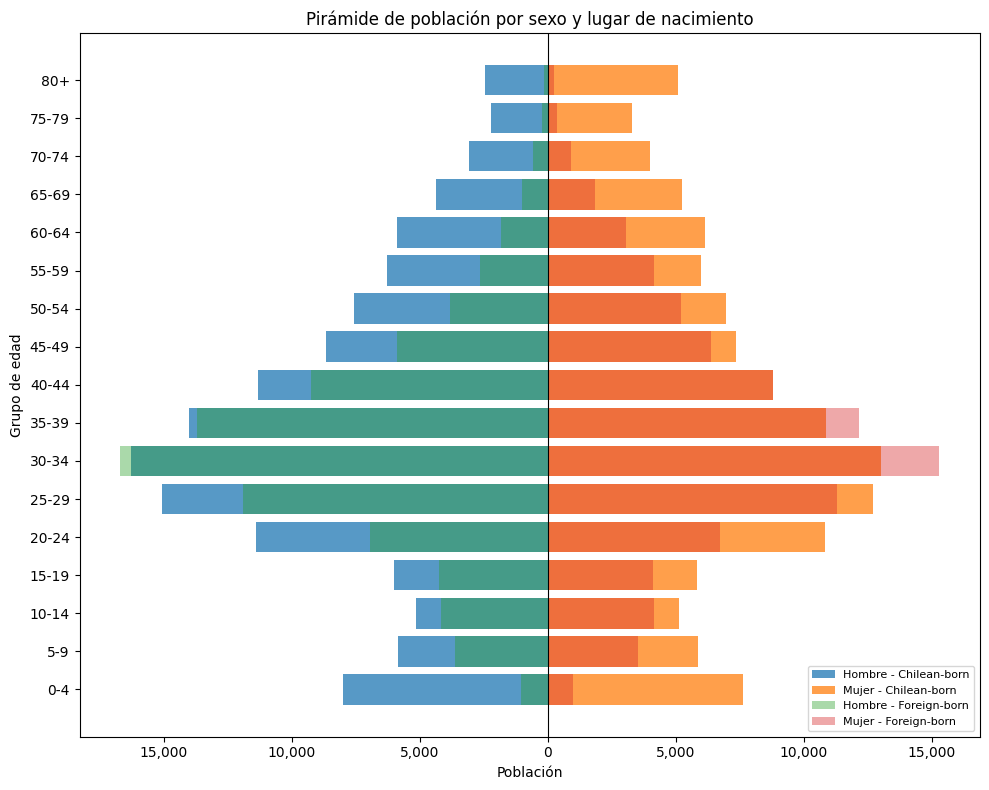

In [11]:
df_age = df[df["edad"].notna()].copy()
df_age, age_labels = normalize_age_group(df_age, age_col="edad")

pyr = (
    df_age.groupby(["age_group", "sexo_label", "born_group"])
          .size()
          .reset_index(name="n")
)

pyr["age_group"] = pd.Categorical(pyr["age_group"], categories=age_labels, ordered=True)
pyr = pyr.sort_values("age_group")

male_label = "Hombre" if "Hombre" in set(df_age["sexo_label"].dropna()) else sorted(df_age["sexo_label"].dropna().unique())[0]
female_label = "Mujer" if "Mujer" in set(df_age["sexo_label"].dropna()) else sorted(df_age["sexo_label"].dropna().unique())[-1]

fig, ax = plt.subplots(figsize=(10, 8))

for born_group, alpha in [("Chilean-born", 0.75), ("Foreign-born", 0.40)]:
    male = pyr[(pyr["sexo_label"] == male_label) & (pyr["born_group"] == born_group)].set_index("age_group")["n"].reindex(age_labels, fill_value=0)
    female = pyr[(pyr["sexo_label"] == female_label) & (pyr["born_group"] == born_group)].set_index("age_group")["n"].reindex(age_labels, fill_value=0)

    ax.barh(age_labels, -male.values, alpha=alpha, label=f"{male_label} - {born_group}")
    ax.barh(age_labels,  female.values, alpha=alpha, label=f"{female_label} - {born_group}")

ax.set_title("Pirámide de población por sexo y lugar de nacimiento")
ax.set_xlabel("Población")
ax.set_ylabel("Grupo de edad")
ax.axvline(0, color="black", linewidth=0.8)
ax.legend(fontsize=8, loc="lower right")

ticks = ax.get_xticks()
ax.set_xticklabels([f"{abs(int(t)):,}" for t in ticks])

plt.tight_layout()
plt.show()

## 12. Parte 1.2 — Razón de dependencia

In [12]:
dependency_table = (
    df.groupby(["codigo_comuna", "nombre_comuna"])
      .apply(lambda g: dependency_ratio_from_series(g["edad"]))
      .reset_index(name="dependency_ratio")
      .sort_values("dependency_ratio", ascending=False)
)

dependency_table

,codigo_comuna,nombre_comuna,dependency_ratio
0,13101,Santiago,0.262107


  
La razón de dependencia obtenida para Santiago es 0.262, lo que indica que por cada 100 personas en edad de trabajar hay aproximadamente 26 personas dependientes (menores de 15 años o mayores de 64). Esto sugiere una carga demográfica relativamente moderada, con predominio de población en edad laboral dentro de la comuna.

## 13. Parte 1.3 — Distribución del tamaño del hogar



- `All Chilean-born` = todos los miembros del hogar nacieron en Chile
- `At least one Foreign-born` = al menos un integrante del hogar nació en el extranjero

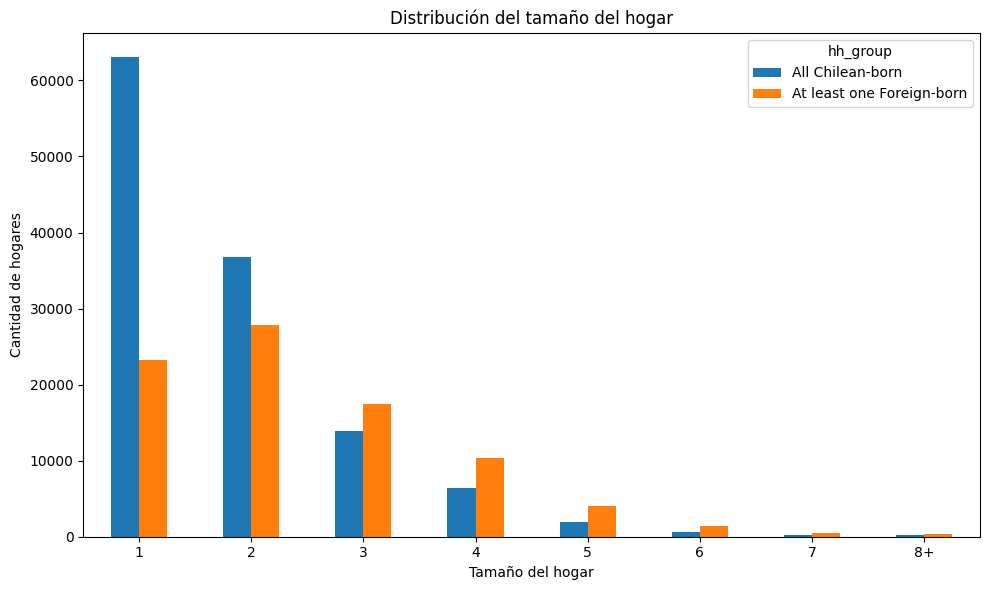

In [13]:
hh = (
    df.groupby(["id_vivienda", "id_hogar", "codigo_comuna", "nombre_comuna"])
      .agg(
          household_size=("id_persona", "nunique"),
          any_foreign=("born_group", lambda x: (x == "Foreign-born").any())
      )
      .reset_index()
)

hh["hh_group"] = np.where(hh["any_foreign"], "At least one Foreign-born", "All Chilean-born")
hh["size_capped"] = hh["household_size"].clip(upper=8)
hh["size_label"] = hh["size_capped"].astype(int).astype(str).replace({"8": "8+"})

hh_dist = (
    hh.groupby(["size_label", "hh_group"])
      .size()
      .reset_index(name="n")
)

order_sizes = [str(i) for i in range(1, 8)] + ["8+"]
hh_dist["size_label"] = pd.Categorical(hh_dist["size_label"], categories=order_sizes, ordered=True)
hh_dist = hh_dist.sort_values(["size_label", "hh_group"])

pivot_hh = hh_dist.pivot(index="size_label", columns="hh_group", values="n").fillna(0)

pivot_hh.plot(kind="bar", figsize=(10, 6))
plt.title("Distribución del tamaño del hogar")
plt.xlabel("Tamaño del hogar")
plt.ylabel("Cantidad de hogares")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


La distribución del tamaño del hogar muestra diferencias claras entre ambos grupos. Los hogares compuestos solo por personas nacidas en Chile se concentran principalmente en tamaños 1 y 2, mientras que los hogares con al menos una persona nacida en el extranjero tienen una mayor presencia relativa en tamaños 2, 3 y 4. Esto sugiere que los hogares con presencia migrante tienden a ser, en promedio, más numerosos que los hogares exclusivamente chilenos.

## 14. Parte 1.4 — Educación y empleo


- escolaridad promedio para 25+,
- tasa de empleo para 15–64,
- y separar por nacidos en Chile vs. nacidos en el extranjero.

In [15]:
school_df = df[(df["edad"] >= 25) & (df["escolaridad"].notna())].copy()
schooling = (
    school_df.groupby(["codigo_comuna", "nombre_comuna", "born_group"])["escolaridad"]
             .mean()
             .reset_index(name="mean_schooling")
)

emp_df = df[(df["edad"] >= 15) & (df["edad"] <= 64) & (df["sit_fuerza_trabajo"].notna())].copy()
emp_df["is_employed"] = emp_df["sit_fuerza_trabajo"].isin(EMPLOYED_CODES).astype(int)

employment = (
    emp_df.groupby(["codigo_comuna", "nombre_comuna", "born_group"])["is_employed"]
          .mean()
          .reset_index(name="employment_rate")
)

display(schooling.head())
display(employment.head())

,codigo_comuna,nombre_comuna,born_group,mean_schooling
0,13101,Santiago,Chilean-born,14.421518
1,13101,Santiago,Foreign-born,13.805328


,codigo_comuna,nombre_comuna,born_group,employment_rate
0,13101,Santiago,Chilean-born,0.726586
1,13101,Santiago,Foreign-born,0.833405


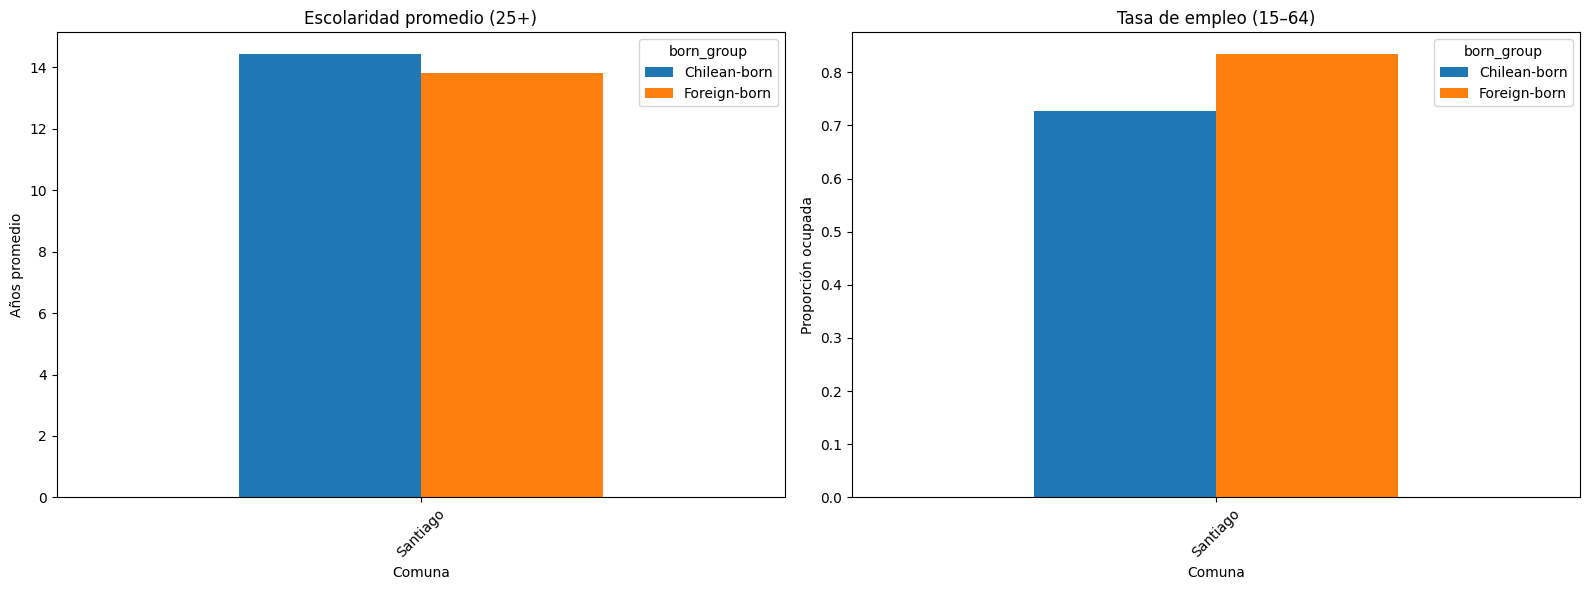

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_school = schooling.pivot(index="nombre_comuna", columns="born_group", values="mean_schooling")
pivot_school.plot(kind="bar", ax=axes[0])
axes[0].set_title("Escolaridad promedio (25+)")
axes[0].set_xlabel("Comuna")
axes[0].set_ylabel("Años promedio")
axes[0].tick_params(axis="x", rotation=45)

pivot_emp = employment.pivot(index="nombre_comuna", columns="born_group", values="employment_rate")
pivot_emp.plot(kind="bar", ax=axes[1])
axes[1].set_title("Tasa de empleo (15–64)")
axes[1].set_xlabel("Comuna")
axes[1].set_ylabel("Proporción ocupada")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

En Santiago, la población nacida en Chile presenta una escolaridad promedio levemente mayor que la población nacida en el extranjero (14.42 años versus 13.81 años). Sin embargo, la tasa de empleo es más alta entre la población extranjera (83.34%) que entre la población nacida en Chile (72.66%). Esto sugiere una inserción laboral muy fuerte de la población migrante, coherente con la concentración observada en edades laborales.

# Parte 2 — Migration Landscape

## 15. Parte 2.1 — Porcentaje de población nacida en el extranjero por comuna

,codigo_comuna,nombre_comuna,pop_total,pop_foreign,pct_foreign
0,13101,Santiago,438856,176956,40.32211


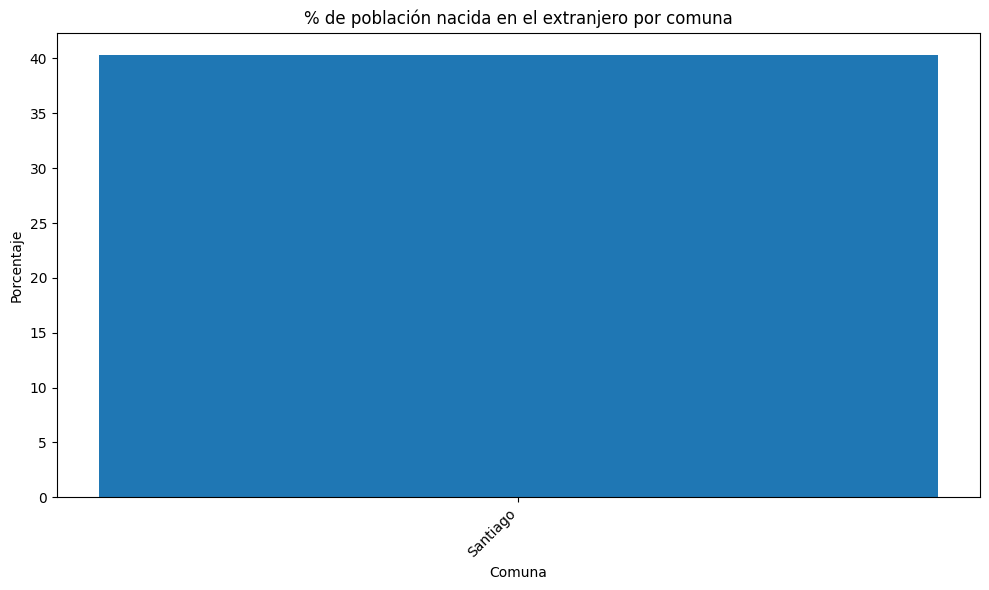

In [17]:
foreign_table = (
    df.groupby(["codigo_comuna", "nombre_comuna"])
      .agg(
          pop_total=("id_persona", "size"),
          pop_foreign=("born_group", lambda x: (x == "Foreign-born").sum())
      )
      .reset_index()
)

foreign_table["pct_foreign"] = 100 * foreign_table["pop_foreign"] / foreign_table["pop_total"]
foreign_table = foreign_table.sort_values("pct_foreign", ascending=False)

display(foreign_table)

plt.figure(figsize=(10, 6))
plt.bar(foreign_table["nombre_comuna"], foreign_table["pct_foreign"])
plt.title("% de población nacida en el extranjero por comuna")
plt.xlabel("Comuna")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. Parte 2.2 — Top 10 nacionalidades



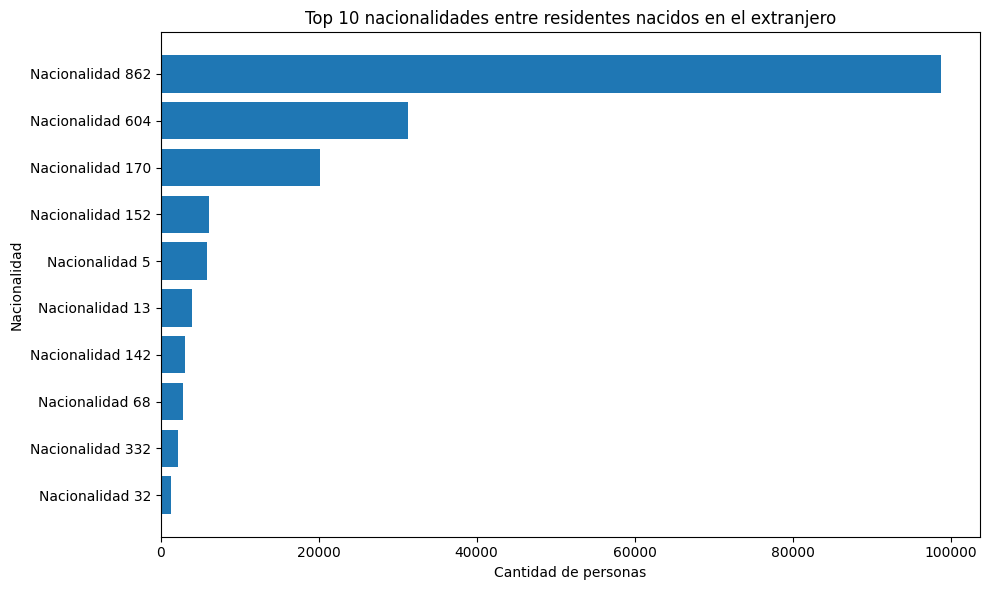

,nationality_label,n
7,Nacionalidad 32,1370
8,Nacionalidad 332,2154
11,Nacionalidad 68,2852
1,Nacionalidad 142,3091
0,Nacionalidad 13,3916
9,Nacionalidad 5,5821
3,Nacionalidad 152,6079
4,Nacionalidad 170,20181
10,Nacionalidad 604,31293
12,Nacionalidad 862,98773


In [18]:
top_nat = (
    df[df["born_group"] == "Foreign-born"]
      .copy()
      .assign(nationality_label=lambda x: x["nationality_label"].fillna("Sin etiqueta"))
      .groupby("nationality_label")
      .size()
      .reset_index(name="n")
      .sort_values("n", ascending=False)
      .head(10)
      .sort_values("n", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(top_nat["nationality_label"], top_nat["n"])
plt.title("Top 10 nacionalidades entre residentes nacidos en el extranjero")
plt.xlabel("Cantidad de personas")
plt.ylabel("Nacionalidad")
plt.tight_layout()
plt.show()

top_nat

La distribución de nacionalidades muestra una alta concentración en pocos grupos. La categoría codificada como 862(Venezuela) domina claramente, seguida por las categorías 604(Perú) y 170(Colombia). En conjunto, las tres principales concentran la mayor parte de la población extranjera observada, lo que sugiere que la migración en Santiago no está distribuida homogéneamente entre muchas nacionalidades, sino que se concentra en unos

## 17. Parte 2.3 — Lugar de residencia hace 5 años

Excluir:

- valores faltantes,
- y personas menores de 5 años.

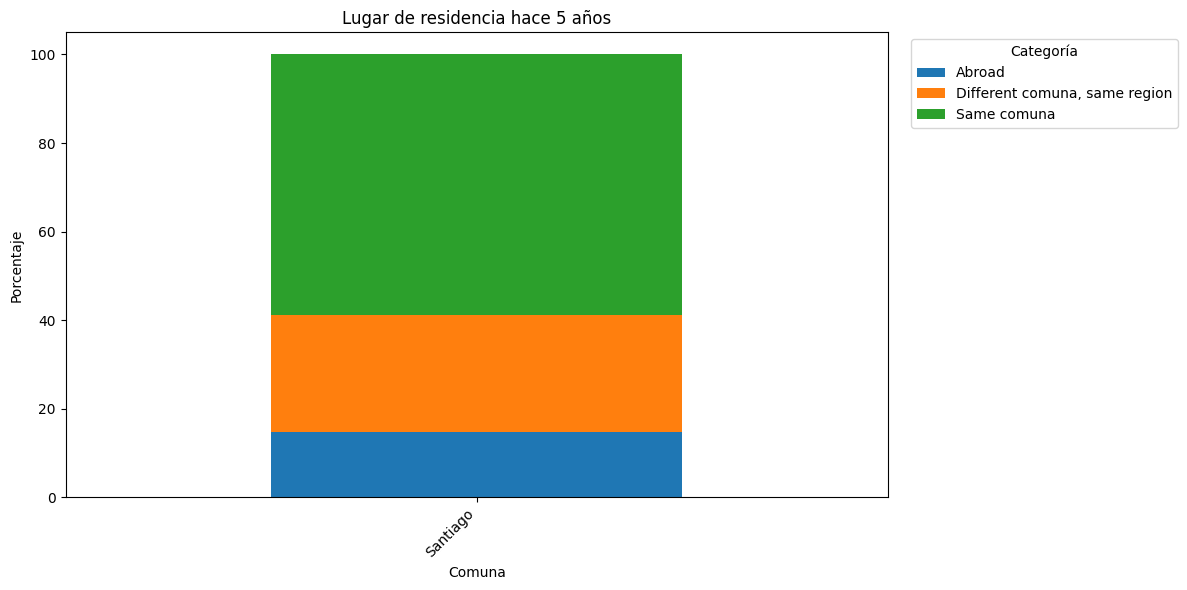

,nombre_comuna,resid5_group,n,pct
2,Santiago,Same comuna,245645,58.836985
1,Santiago,"Different comuna, same region",110106,26.372631
0,Santiago,Abroad,61750,14.790384


In [ ]:
resid5_df = df[(df["edad"] >= 5) & (df["resid5_group"].notna())].copy()

resid5_tab = (
    resid5_df.groupby(["nombre_comuna", "resid5_group"])
             .size()
             .reset_index(name="n")
)

resid5_tab["pct"] = resid5_tab.groupby("nombre_comuna")["n"].transform(lambda x: 100 * x / x.sum())

pivot_resid5 = resid5_tab.pivot(index="nombre_comuna", columns="resid5_group", values="pct").fillna(0)

pivot_resid5.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Lugar de residencia hace 5 años")
plt.xlabel("Comuna")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

resid5_tab.sort_values(["nombre_comuna", "pct"], ascending=[True, False]).head(20)

La mayoría de la población de Santiago vivía en la misma comuna hace 5 años (58.84%), lo que indica una importante permanencia territorial. Al mismo tiempo, un 26.37% vivía en otra comuna de la misma región, lo que refleja movilidad intrarregional relevante. Además, un 14.79% residía en el extranjero, lo que confirma la importancia del componente migratorio reciente en la comuna.

## 18. Parte 2.4 — Período de llegada de inmigrantes

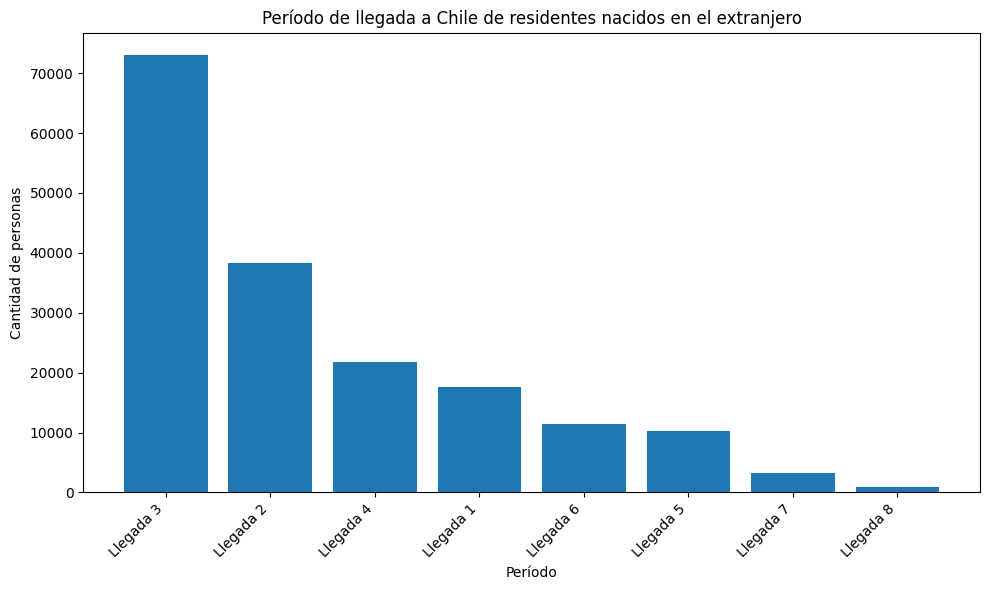

,arrival_label,n
2,Llegada 3,73073
1,Llegada 2,38333
3,Llegada 4,21801
0,Llegada 1,17562
5,Llegada 6,11364
4,Llegada 5,10320
6,Llegada 7,3256
7,Llegada 8,955


In [ ]:
arrival_df = (
    df[(df["born_group"] == "Foreign-born") & (df["arrival_label"].notna())]
      .groupby("arrival_label")
      .size()
      .reset_index(name="n")
      .sort_values("n", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(arrival_df["arrival_label"], arrival_df["n"])
plt.title("Período de llegada a Chile de residentes nacidos en el extranjero")
plt.xlabel("Período")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

arrival_df

La llegada de población extranjera no se distribuye de forma uniforme entre todos los períodos, sino que se concentra especialmente en las categorías Llegada 3(entre 2017-2019), Llegada 2(entre 2020-2022) y Llegada 4(2014-2016). Esto muestra que el crecimiento migratorio en Santiago se ha concentrado en ciertos períodos específicos, más que en una llegada homogénea a lo largo del tiempo.

# Parte 3 — Spatial Visualization

## 19. Cargar cartografía


- `comunas.shp`




In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

# Renombrar los archivos del shapefile si tienen '(1)' en su nombre
if os.path.exists("comunas (1).shx") and not os.path.exists("comunas.shx"):
    os.rename("comunas (1).shx", "comunas.shx")
    print("Renombrado 'comunas (1).shx' a 'comunas.shx'.")

# FIX: Added renaming for .shp file itself
if os.path.exists("comunas (1).shp") and not os.path.exists("comunas.shp"):
    os.rename("comunas (1).shp", "comunas.shp")
    print("Renombrado 'comunas (1).shp' a 'comunas.shp'.")

# 1) Leer shapefile correcto
# Asegurarse de que el resto de los archivos del shapefile (.dbf, .prj, etc.) estén también presentes
comunas_gdf = gpd.read_file("comunas.shp")

# 2) Construir tabla para mapa
# OJO: pop_total debe ser size, no nunique()
df_personas = df.drop_duplicates(subset=["id_vivienda", "id_hogar", "id_persona"]).copy()

foreign_table = (
    df_personas.groupby(["codigo_comuna", "nombre_comuna"])
      .agg(
          pop_total=("id_persona", "size"),
          pop_foreign=("born_group", lambda x: (x == "Foreign-born").sum())
      )
      .reset_index()
)

foreign_table["pct_foreign"] = 100 * foreign_table["pop_foreign"] / foreign_table["pop_total"]

# 3) Asegurar mismo tipo de dato para merge
comunas_gdf["cod_comuna"] = pd.to_numeric(comunas_gdf["cod_comuna"], errors="coerce")
foreign_table["codigo_comuna"] = pd.to_numeric(foreign_table["codigo_comuna"], errors="coerce")

# 4) Unir shapefile con tabla resumen
gdf_map = comunas_gdf.merge(
    foreign_table,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="inner"
)

gdf_map[["Comuna", "cod_comuna", "pop_total", "pct_foreign"]].head()

Renombrado 'comunas (1).shp' a 'comunas.shp'.


,Comuna,cod_comuna,pop_total,pct_foreign
0,Santiago,13101,438856,40.32211


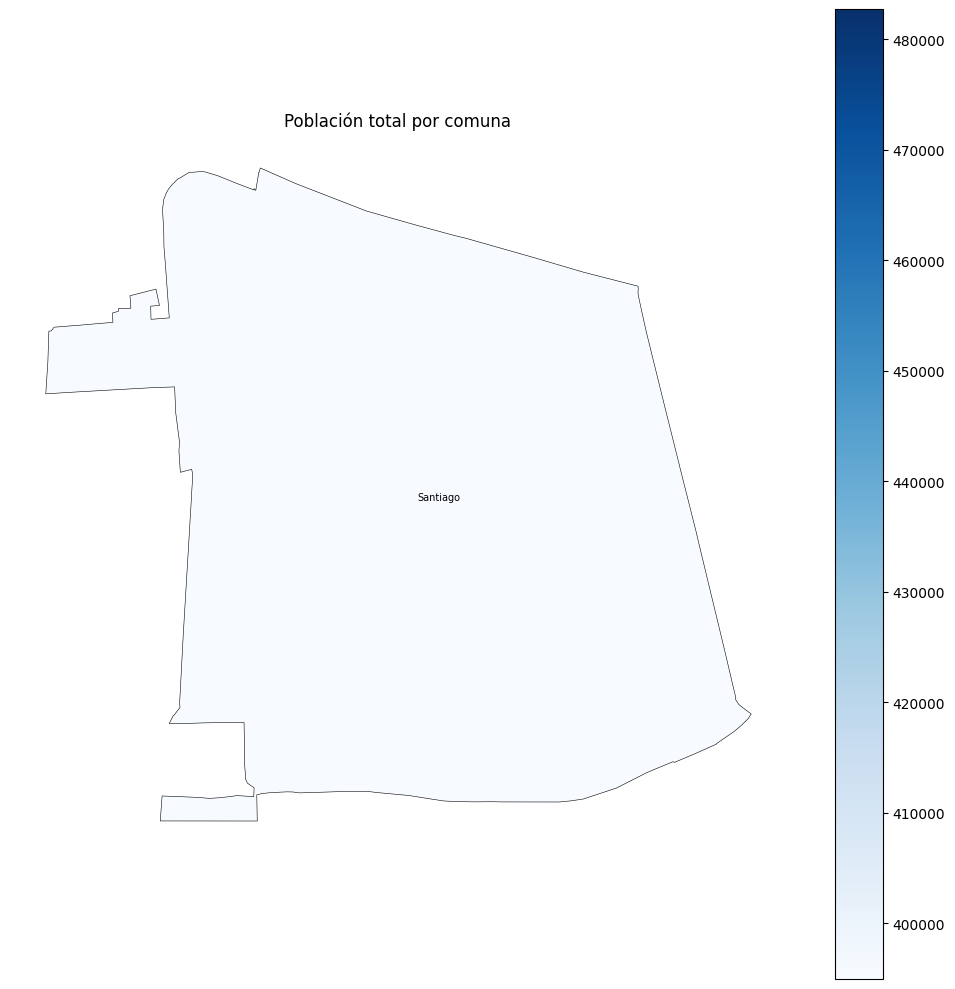

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_map.plot(
    column="pop_total",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)
ax.set_title("Población total por comuna")
ax.axis("off")

rep_points = gdf_map.representative_point()
for x, y, label in zip(rep_points.x, rep_points.y, gdf_map["Comuna"]):
    ax.text(x, y, str(label), fontsize=7, ha="center")

plt.tight_layout()
plt.show()

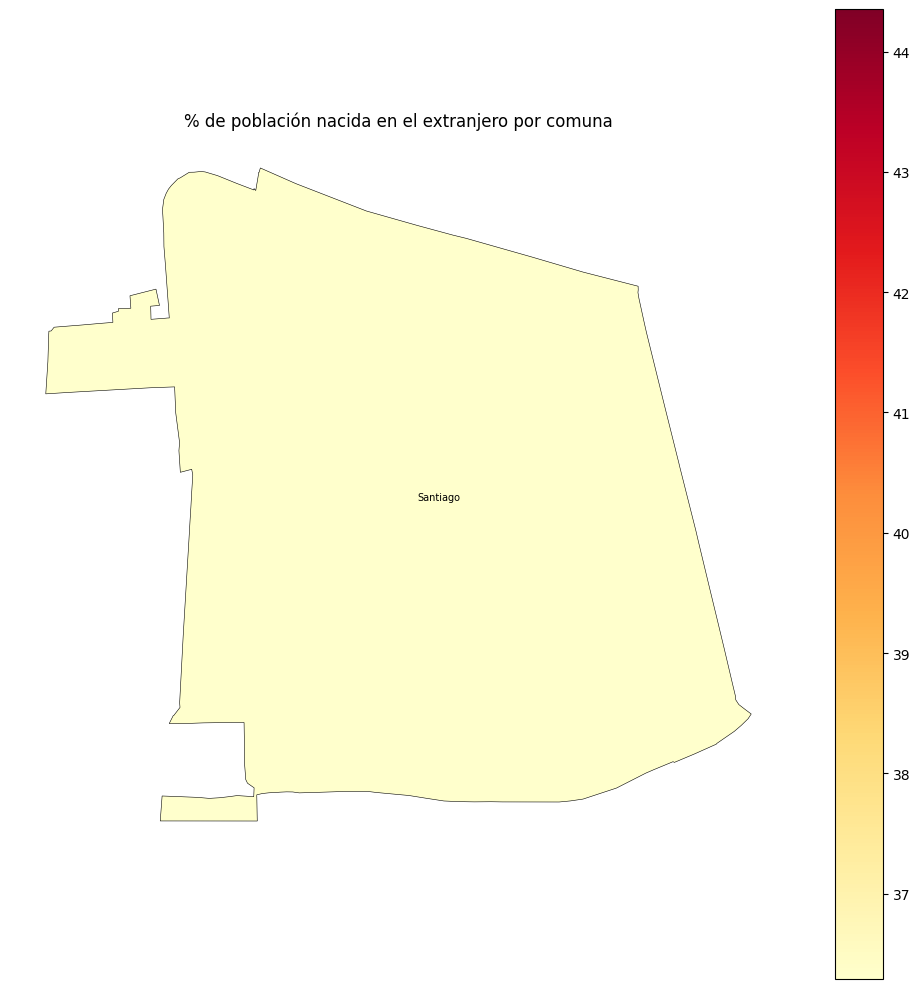

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_map.plot(
    column="pct_foreign",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)
ax.set_title("% de población nacida en el extranjero por comuna")
ax.axis("off")

rep_points = gdf_map.representative_point()
for x, y, label in zip(rep_points.x, rep_points.y, gdf_map["Comuna"]):
    ax.text(x, y, str(label), fontsize=7, ha="center")

plt.tight_layout()
plt.show()

## 20. Preparar datos para el mapa

In [ ]:
map_df = foreign_table.copy()

if comunas_gdf is not None:
    candidate_code_cols = ["codigo_comuna", "CODIGO", "CUT_COM", "CUT_COMUNA", "cod_comuna", "comuna"]
    candidate_name_cols = ["nombre_comuna", "NOM_COM", "COMUNA", "NOMBRE"]

    geo_code_col = next((c for c in candidate_code_cols if c in comunas_gdf.columns), None)
    geo_name_col = next((c for c in candidate_name_cols if c in comunas_gdf.columns), None)

    if geo_code_col is None:
        raise ValueError("No pude detectar la columna con código de comuna en la cartografía.")

    comunas_gdf[geo_code_col] = pd.to_numeric(comunas_gdf[geo_code_col], errors="coerce")
    map_df["codigo_comuna"] = pd.to_numeric(map_df["codigo_comuna"], errors="coerce")

    gdf_map = comunas_gdf.merge(map_df, left_on=geo_code_col, right_on="codigo_comuna", how="inner")

    if geo_name_col is not None and "nombre_comuna" in gdf_map.columns:
        gdf_map["label_comuna"] = gdf_map["nombre_comuna"]
    elif geo_name_col is not None:
        gdf_map["label_comuna"] = gdf_map[geo_name_col]
    else:
        gdf_map["label_comuna"] = gdf_map["codigo_comuna"].astype(str)

    display(gdf_map.head())
else:
    gdf_map = None

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry,codigo_comuna,nombre_comuna,pop_total,pop_foreign,pct_foreign,label_comuna
0,333,24644.018619,10,7,13101,13,3.337678e+07,29171.6095,Región Metropolitana de Santiago,Santiago,Santiago,"POLYGON ((-7864917.074 -3952801.626, -7864220....",13101,Santiago,438856,176956,40.32211,13101


## 21. Parte 3.1 — Mapa coroplético de población total

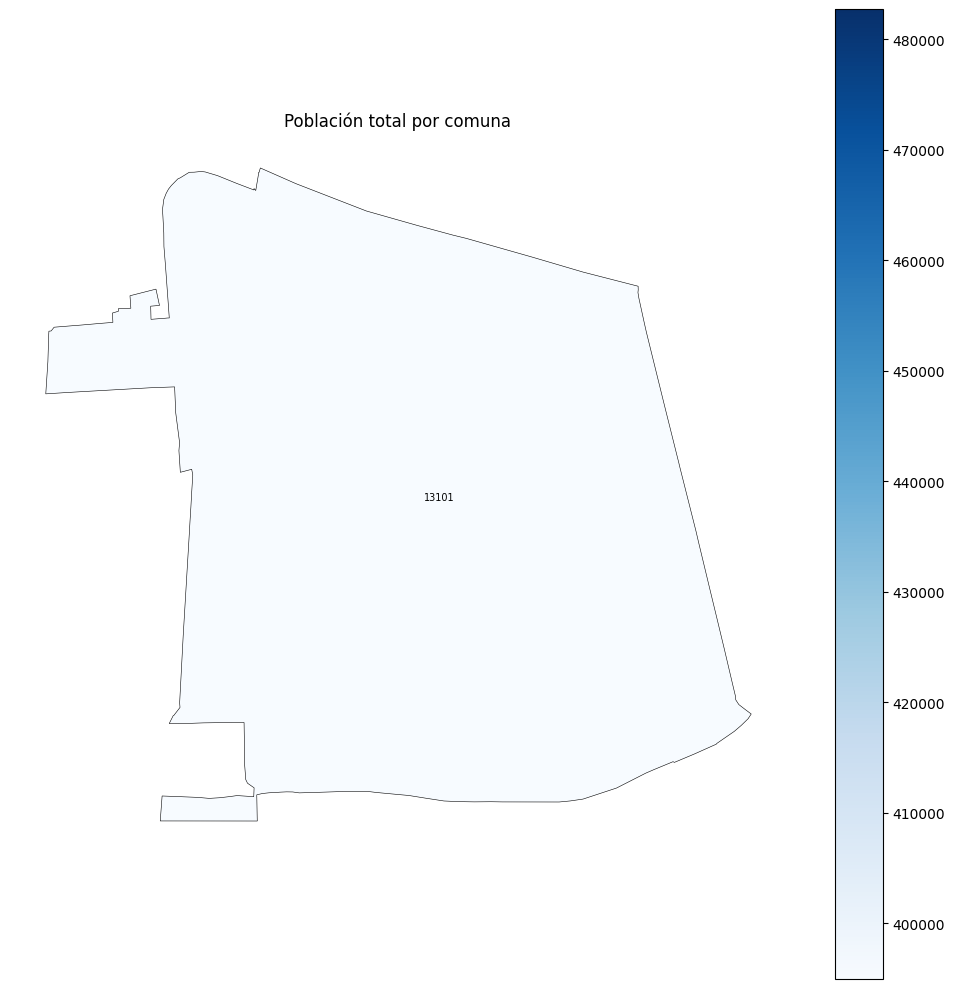

In [ ]:
if gdf_map is not None:
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_map.plot(column="pop_total", cmap="Blues", legend=True, edgecolor="black", linewidth=0.4, ax=ax)
    ax.set_title("Población total por comuna")
    ax.axis("off")

    rep_points = gdf_map.representative_point()
    for x, y, label in zip(rep_points.x, rep_points.y, gdf_map["label_comuna"]):
        ax.text(x, y, str(label), fontsize=7, ha="center")

    plt.tight_layout()
    plt.show()
else:
    print("No se pudo generar el mapa porque falta la cartografía.")

## 22. Parte 3.2 — Mapa coroplético de % foreign-born

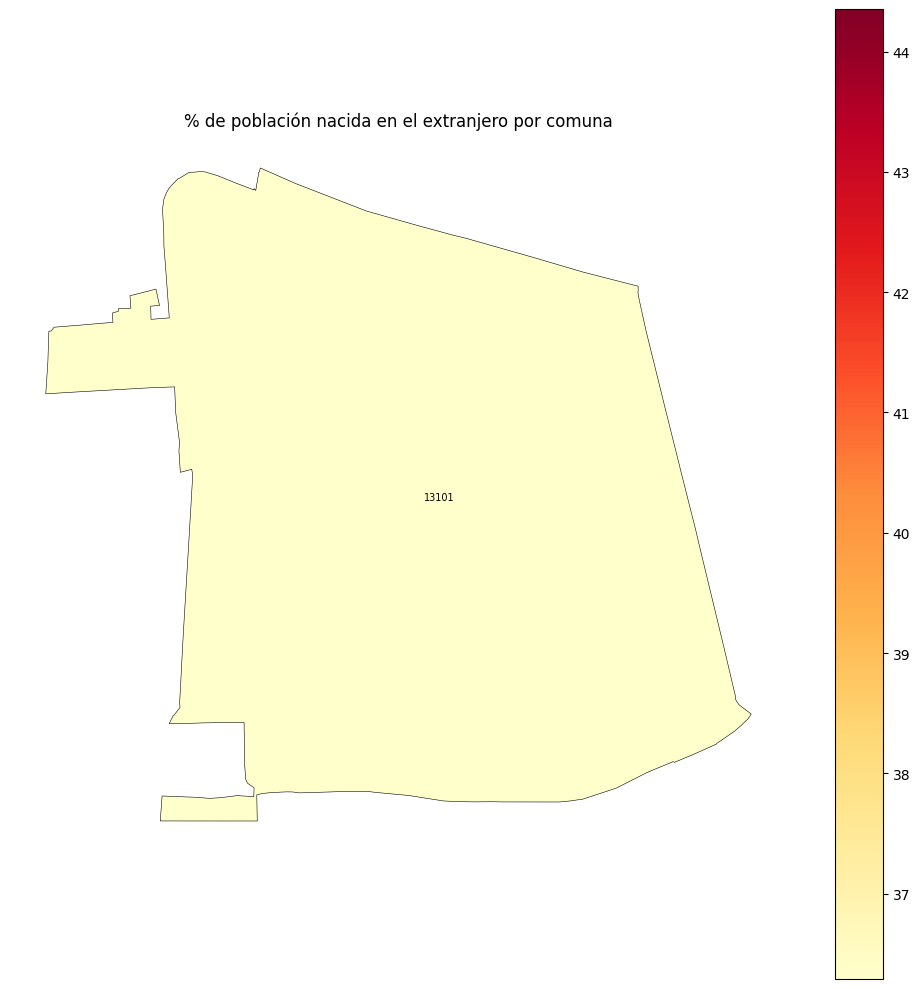

In [ ]:
if gdf_map is not None:
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_map.plot(column="pct_foreign", cmap="YlOrRd", legend=True, edgecolor="black", linewidth=0.4, ax=ax)
    ax.set_title("% de población nacida en el extranjero por comuna")
    ax.axis("off")

    rep_points = gdf_map.representative_point()
    for x, y, label in zip(rep_points.x, rep_points.y, gdf_map["label_comuna"]):
        ax.text(x, y, str(label), fontsize=7, ha="center")

    plt.tight_layout()
    plt.show()
else:
    print("No se pudo generar el mapa porque falta la cartografía.")

# Parte 4 — Comuna-Level Summary Table

## 23. Construcción de la tabla resumen comunal

Esta es la salida más importante de la tarea y debe:

- mostrarse en el notebook,
- y guardarse como CSV para reutilizarse en la Tarea 3.

In [ ]:
def build_summary(group):
    schooling_25 = group[(group["edad"] >= 25) & (group["escolaridad"].notna())]
    emp_15_64 = group[(group["edad"] >= 15) & (group["edad"] <= 64) & (group["sit_fuerza_trabajo"].notna())].copy()
    emp_15_64["is_employed"] = emp_15_64["sit_fuerza_trabajo"].isin(EMPLOYED_CODES).astype(int)

    out = pd.Series({
        "nombre_comuna": group["nombre_comuna"].iloc[0],
        "pop_total": group["id_persona"].size,
        "pop_chilean": (group["born_group"] == "Chilean-born").sum(),
        "pop_foreign": (group["born_group"] == "Foreign-born").sum(),
        "pct_foreign": 100 * (group["born_group"] == "Foreign-born").sum() / group["id_persona"].size,
        "median_age_chilean": group.loc[group["born_group"] == "Chilean-born", "edad"].median(),
        "median_age_foreign": group.loc[group["born_group"] == "Foreign-born", "edad"].median(),
        "mean_schooling_chilean": schooling_25.loc[schooling_25["born_group"] == "Chilean-born", "escolaridad"].mean(),
        "mean_schooling_foreign": schooling_25.loc[schooling_25["born_group"] == "Foreign-born", "escolaridad"].mean(),
        "emp_rate_chilean": emp_15_64.loc[emp_15_64["born_group"] == "Chilean-born", "is_employed"].mean(),
        "emp_rate_foreign": emp_15_64.loc[emp_15_64["born_group"] == "Foreign-born", "is_employed"].mean(),
        "dependency_ratio": dependency_ratio_from_series(group["edad"]),
    })
    return out

summary = (
    df.groupby("codigo_comuna")
      .apply(build_summary)
      .reset_index()
      .sort_values("codigo_comuna")
)

summary

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13101,Santiago,438856,258429,176956,40.32211,35.0,34.0,14.421518,13.805328,0.726586,0.833405,0.262107


In [ ]:
summary_path = os.path.join(OUTPUT_DIR, "tarea1_comuna_summary.csv")
summary.to_csv(summary_path, index=False)

print("CSV guardado en:")
print(summary_path)

In [ ]:
summary_path = os.path.join(OUTPUT_DIR, "tarea1_comuna_summary.csv")
summary.to_csv(summary_path, index=False)

print("CSV guardado en:")
print(summary_path)

In [ ]:
summary_path = os.path.join(OUTPUT_DIR, "tarea1_comuna_summary.csv")
summary.to_csv(summary_path, index=False)

print("CSV guardado en:")
print(summary_path)

In [ ]:
summary_path = os.path.join(OUTPUT_DIR, "tarea1_comuna_summary.csv")
summary.to_csv(summary_path, index=False)

print("CSV guardado en:")
print(summary_path)

In [ ]:
summary_path = os.path.join(OUTPUT_DIR, "tarea1_comuna_summary.csv")
summary.to_csv(summary_path, index=False)

print("CSV guardado en:")
print(summary_path)

CSV guardado en:
output/tarea1_comuna_summary.csv


## 24. Conclusiones

En síntesis, Santiago presenta una estructura demográfica fuertemente marcada por la migración internacional. La población nacida en el extranjero representa una proporción muy alta del total comunal, se concentra sobre todo en edades laborales y exhibe una tasa de empleo superior a la de la población nacida en Chile. Además, los hogares con presencia migrante tienden a ser más grandes y la movilidad observada hace 5 años confirma tanto permanencia comunal como un componente importante de llegada desde el extranjero. En conjunto, estos resultados muestran que la migración es un factor central para entender la composición y dinámica actual de la comuna de Santiago.